# **Problem Understanding & Initial EDA**

# Problem Statement

Hotel booking cancellations are a major challenge for the hospitality industry because they affect revenue, room occupancy planning, staffing decisions, and overall business operations.

The objective of this project is to analyze hotel booking data and develop a machine learning model that can predict whether a booking will be canceled based on customer and reservation information.

By identifying the factors associated with cancellations, hotels can take proactive measures to reduce cancellation rates and improve operational efficiency.

## Target Variable

**is_canceled**

- 1 = Booking Canceled
- 0 = Booking Not Canceled

## Project Goal

To build a classification model that predicts whether a hotel booking will be canceled.

# Dataset Description

The Hotel Booking Demand dataset contains booking information for both Resort Hotels and City Hotels.

The dataset includes customer details, reservation information, booking history, stay duration, room assignments, pricing information, and booking outcomes.

## Dataset Characteristics

- More than 119,000 booking records
- Numerical and categorical features
- Real-world hotel booking information
- Missing values requiring preprocessing
- Suitable for predictive analytics and classification tasks

## Examples of Features

- hotel
- lead_time
- meal
- country
- market_segment
- deposit_type
- customer_type
- adr (Average Daily Rate)
- total_of_special_requests

## Target Variable

The target variable is:

**is_canceled**

The objective is to predict whether a booking will be canceled using the available booking information.

## **Load Dataset**

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\user\OneDrive\Desktop\Machine Learning Project\Data\hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## **Check Dataset Shape**

In [3]:
df.shape

(119390, 32)

## **Dataset Structure**

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

## **Identify Target Variable**

In [5]:
target_variable = "is_canceled"
print("Target Variable:", target_variable)

Target Variable: is_canceled


## **Summary Statistics**

In [6]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


## **Numerical Features**

In [7]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
numerical_features

Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='str')

## **Categorical Features**

In [8]:
categorical_features = df.select_dtypes(include=['string']).columns
categorical_features

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='str')

## **Missing Values**

In [9]:
df.isnull().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

# **Exploratory Data Analysis**

EDA is performed to understand the characteristics of the dataset and identify patterns that may influence hotel booking cancellations.

The objectives of EDA are:

- Understand booking behavior
- Identify important variables
- Detect missing values
- Detect outliers
- Examine relationships between variables
- Explore factors influencing cancellations

## **Hotel Type vs Cancellation**

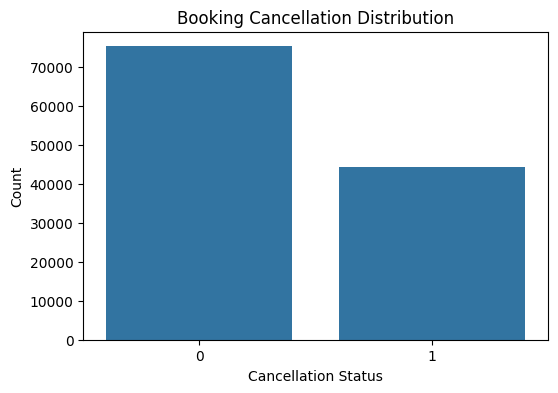

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='is_canceled',
    data=df
)

plt.title('Booking Cancellation Distribution')
plt.xlabel('Cancellation Status')
plt.ylabel('Count')

plt.show()

## **Lead Time Distribution**

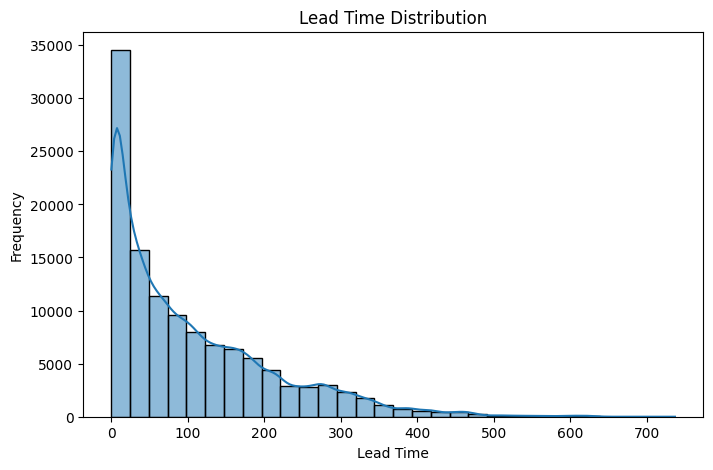

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['lead_time'],
    bins=30,
    kde=True
)

plt.title('Lead Time Distribution')
plt.xlabel('Lead Time')
plt.ylabel('Frequency')

plt.show()

## **Lead Time vs ADR (Scatter Plot)**

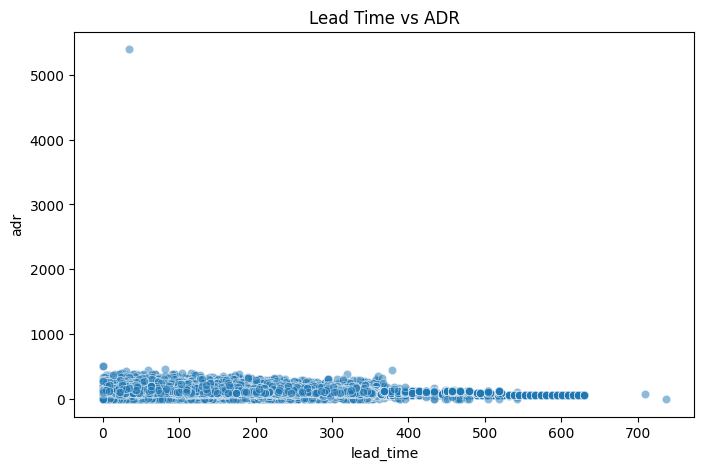

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='lead_time',
    y='adr',
    data=df,
    alpha=0.5
)

plt.title('Lead Time vs ADR')

plt.show()

## **Hotel Type vs Cancellation**

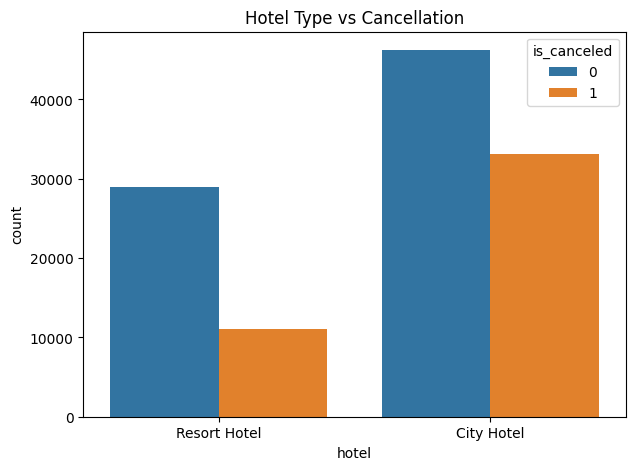

In [13]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='hotel',
    hue='is_canceled',
    data=df
)

plt.title('Hotel Type vs Cancellation')

plt.show()

## **Top Feature Relationships Heatmap**

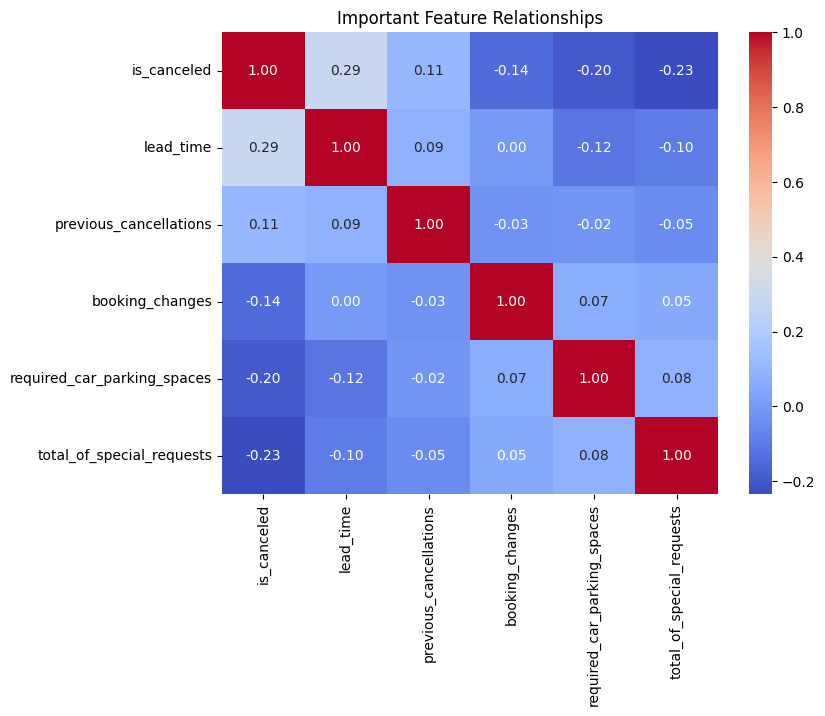

In [14]:
corr_matrix = df.corr(numeric_only=True)

target_corr = corr_matrix['is_canceled'].abs()

important_features = target_corr[
    target_corr > 0.10
].index
plt.figure(figsize=(8,6))
sns.heatmap(df[important_features].corr(),annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Important Feature Relationships')

plt.show()

## **Monthly Booking Trends**

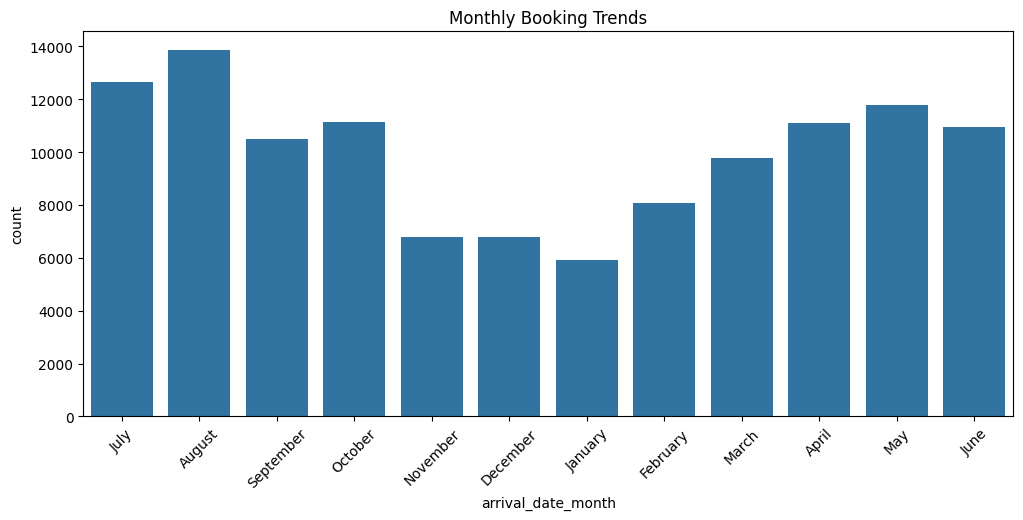

In [15]:
plt.figure(figsize=(12,5))

sns.countplot(x='arrival_date_month', data=df)

plt.xticks(rotation=45)
plt.title('Monthly Booking Trends')
plt.show()

## **Outlier Detection**

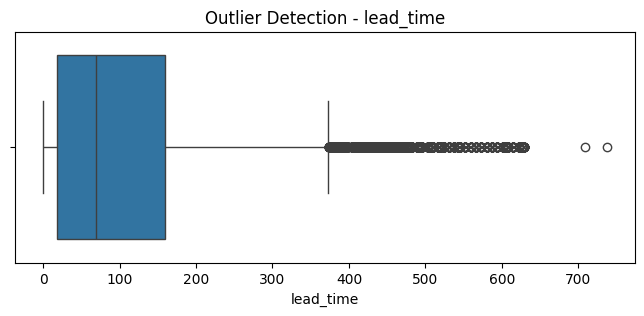

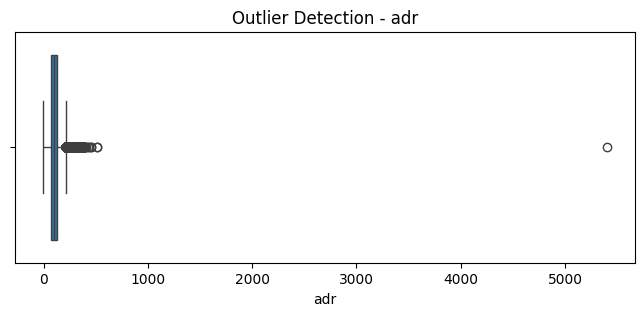

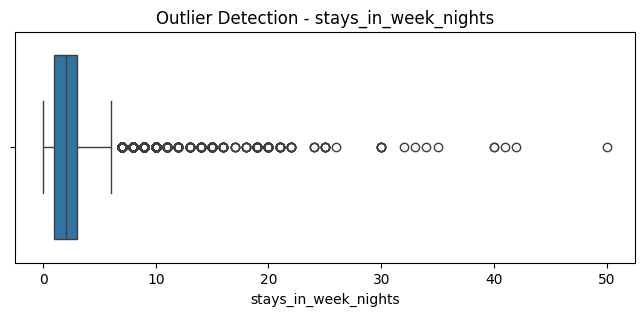

In [17]:
outlier_columns = [
    'lead_time',
    'adr',
    'stays_in_week_nights'
]

for col in outlier_columns:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f'Outlier Detection - {col}')
    plt.show()

# Key Patterns Discovered

### 1. Booking Cancellations
A significant portion of hotel bookings were canceled, indicating the importance of understanding cancellation behavior.

### 2. Lead Time Influence
Bookings made far in advance tend to show higher cancellation rates.

### 3. Hotel Type Differences
City Hotels appear to experience higher cancellation rates than Resort Hotels.

### 4. Missing Values
Several columns contain missing values, particularly company and agent.

### 5. Outliers
Outliers were identified in variables such as ADR,weak nights and lead_time.

### 6. Customer Behavior
Variables related to previous bookings, special requests, and repeated guests appear to influence cancellation behavior.

### 7. Important Predictors
Initial correlation analysis suggests that lead_time, previous_cancellations, total_of_special_requests, and repeated_guest status may be important predictors.